# LangGraph Liver/Tumor Segmentation Inference Pipeline

This notebook runs a per-case LangGraph pipeline for A/P/D phase liver tumor inference.

Input-dependent flow:

1. Prepare A/P/D inputs and infer `input_format` (`nifti` or `dicom`).
2. For NIfTI inputs, skip resampling/registration at first and run liver extraction directly on the input volumes.
3. If the initial NIfTI liver mean Dice is `>= 0.95`, go directly to tumor extraction.
4. If the initial NIfTI liver mean Dice is `< 0.95`, start registration from hyperparameter Attempt 2.
5. For DICOM inputs, convert to NIfTI, run resampling, then start registration from hyperparameter Attempt 1.
6. Retry registration up to 5 attempts until the liver mean Dice passes the threshold.
7. If the liver gate succeeds, run independent tumor inference for UNet, SwinUNETR, 3DSAM-adapter, and nnUNetv2.
8. Save every input check, registration attempt, liver mask, tumor prediction, metrics, and summary under `Results/{case_id}/`.

Notes:
- `langgraph/files/registration.py`, `resampler.py`, and `liver_extractor.py` are used for the pipeline stages.
- `REGISTRATION_CONFIGS` from `langgraph/files/config.py` controls registration hyperparameters.
- `input_format="auto"` infers the mode from the A/P/D paths. Set it explicitly to `"nifti"` or `"dicom"` when needed.


In [28]:
from __future__ import annotations

import json
import shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Optional, TypedDict

import numpy as np
import pandas as pd
import SimpleITK as sitk
import torch
try:
    from langgraph.graph import END, START, StateGraph
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "LangGraph is required for this notebook. Install it in this environment with: pip install langgraph"
    ) from exc

from config import DATA_PATH1, DATA_PATH2
from main import format_path_part
from langgraph.files.config import REGISTRATION_CONFIGS
from langgraph.files.resampler import Resampler
from langgraph.files.registration import Registration
from langgraph.files.inference_unet import run_unet
from langgraph.files.inference_swinunetr import run_swinunetr
from langgraph.files.inference_sam_adapter import run_sam_adapter
from langgraph.files.inference_nnunetv2 import run_nnunetv2

try:
    from externalregis import extract_segmentation as fallback_extract_liver
except Exception as exc:
    fallback_extract_liver = None
    print(f"externalregis liver extraction fallback unavailable: {exc}")


In [ ]:
@dataclass
class PipelineConfig:
    excel_path: str = "./alldata_metrics.xlsx"
    data_root1: str = DATA_PATH1
    data_root2: str = DATA_PATH2
    results_root: str = "./Results"
    test_size: int = 34
    liver_dice_threshold: float = 0.95
    max_registration_attempts: int = 5
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Input handling.
    # auto: infer from A/P/D paths. nifti: start from liver Dice check. dicom: resample + registration attempt 1.
    input_format: str = "auto"

    # Tumor inference selection.
    # Pick a subset like ("unet",) for a single model, or keep all four to run them together.
    models: tuple[str, ...] = ("unet", "swinunetr", "sam3d_adapter", "nnunetv2")

    # Direct model inference settings
    window: tuple[float, float] = (-200, 300)
    roi_size: tuple[int, int, int] = (96, 128, 128)
    sw_batch_size: int = 4
    sw_overlap: float = 0.5
    sw_mode: str = "gaussian"
    threshold: float = 0.5

    # Model architecture args must match training.
    channels: tuple[int, ...] = (16, 32, 64, 128, 256)
    strides: tuple[int, ...] = (2, 2, 2, 2)
    num_res_units: int = 2
    img_size: tuple[int, int, int] = (96, 384, 384)
    feature_size: int = 48
    use_checkpoint: bool = False
    sam_patch_size: int = 16
    sam_tubelet_size: int = 16
    sam_embed_dim: int = 128
    sam_depth: int = 4
    sam_num_heads: int = 4
    sam_encoder_channels: int = 128
    sam_decoder_channels: int = 64
    sam_adapter_ratio: float = 0.5

    checkpoints: Dict[str, str] = None

    # nnUNetv2 settings
    nnunet_input_dir: str = "./nnUNet/nnUNet_raw/Dataset001/imagesTs"
    nnunet_dataset: str = "001"
    nnunet_config: str = "3d_fullres"
    nnunet_save_probabilities: bool = True
    nnunet_raw: Optional[str] = None
    nnunet_preprocessed: Optional[str] = None
    nnunet_results: Optional[str] = None

    def __post_init__(self):
        if self.checkpoints is None:
            self.checkpoints = {
                "unet": "./checkpoints/unet/best_model.pt",
                "swinunetr": "./checkpoints/swinunetr/best_model.pt",
                "sam3d_adapter": "./checkpoints/sam_adapter/best_model.pt",
            }

CFG = PipelineConfig()
Path(CFG.results_root).mkdir(parents=True, exist_ok=True)
asdict(CFG)


In [30]:
def load_test_dataframe(cfg: PipelineConfig) -> pd.DataFrame:
    data = pd.read_excel(cfg.excel_path)
    data = data.sort_values("tumor_size").reset_index(drop=True)
    return data.iloc[:cfg.test_size].copy()


def get_case_from_row(row: pd.Series, cfg: PipelineConfig) -> Dict[str, Any]:
    subject = format_path_part(row["subject"])
    date = format_path_part(row["date"])
    if date == "0":
        source_dir = Path(cfg.data_root2) / subject
        case_id = subject
    else:
        source_dir = Path(cfg.data_root1) / subject / date
        case_id = f"{subject}_{date}"

    return {
        "subject": subject,
        "date": date,
        "case_id": case_id,
        "source_dir": str(source_dir),
        "A": str(source_dir / "A.nii.gz"),
        "P": str(source_dir / "P.nii.gz"),
        "D": str(source_dir / "D.nii.gz"),
        "label": str(source_dir / "label.nii.gz"),
    }


def expected_test_case_ids(cfg: PipelineConfig) -> List[str]:
    return [get_case_from_row(row, cfg)["case_id"] for _, row in load_test_dataframe(cfg).iterrows()]


def get_test_cases(cfg: PipelineConfig) -> List[Dict[str, Any]]:
    df = load_test_dataframe(cfg)
    cases = []
    for _, row in df.iterrows():
        case = get_case_from_row(row, cfg)
        required = [case["A"], case["P"], case["D"], case["label"]]
        if all(Path(p).exists() for p in required):
            cases.append(case)
        else:
            print(f"skip missing case: {case['case_id']}")
    return cases


def is_nifti_path(path: str | Path) -> bool:
    path = Path(path)
    name = path.name.lower()
    return path.is_file() and (name.endswith(".nii") or name.endswith(".nii.gz"))


def contains_dicom_files(path: str | Path) -> bool:
    path = Path(path)
    if path.is_file():
        suffix = path.suffix.lower()
        return suffix in {".dcm", ".ima"}
    if not path.is_dir():
        return False
    return any(p.suffix.lower() in {".dcm", ".ima"} for p in path.rglob("*"))


def infer_input_format(case: Dict[str, Any], cfg: PipelineConfig) -> str:
    if cfg.input_format != "auto":
        return cfg.input_format

    phase_paths = [case[phase] for phase in ("A", "P", "D")]
    if all(is_nifti_path(path) for path in phase_paths):
        return "nifti"
    if all(contains_dicom_files(path) for path in phase_paths):
        return "dicom"
    raise ValueError(
        f"Could not infer input format for {case['case_id']}. "
        "Expected all A/P/D inputs to be NIfTI files or all to be DICOM directories/files."
    )


def dicom_to_nifti(dicom_path: str | Path, output_path: str | Path) -> str:
    dicom_path = Path(dicom_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if dicom_path.is_file():
        reader = sitk.ImageFileReader()
        reader.SetFileName(str(dicom_path))
        image = reader.Execute()
    else:
        series_ids = sitk.ImageSeriesReader.GetGDCMSeriesIDs(str(dicom_path))
        if not series_ids:
            raise FileNotFoundError(f"No DICOM series found in {dicom_path}")
        series_files = [
            sitk.ImageSeriesReader.GetGDCMSeriesFileNames(str(dicom_path), series_id)
            for series_id in series_ids
        ]
        dicom_files = max(series_files, key=len)
        reader = sitk.ImageSeriesReader()
        reader.SetFileNames(dicom_files)
        image = reader.Execute()

    sitk.WriteImage(image, str(output_path))
    return str(output_path)


def prepare_phase_inputs(case: Dict[str, Any], case_result_dir: Path, cfg: PipelineConfig) -> tuple[Path, str]:
    input_format = infer_input_format(case, cfg)

    if input_format == "nifti":
        input_dir = case_result_dir / "input"
        input_dir.mkdir(parents=True, exist_ok=True)
        for phase in ("A", "P", "D"):
            shutil.copy2(case[phase], input_dir / f"{phase}.nii.gz")
        return input_dir, input_format

    if input_format == "dicom":
        input_dir = case_result_dir / "dicom_nifti"
        input_dir.mkdir(parents=True, exist_ok=True)
        for phase in ("A", "P", "D"):
            dicom_to_nifti(case[phase], input_dir / f"{phase}.nii.gz")
        return input_dir, input_format

    raise ValueError(f"Unsupported input_format: {input_format}")


def nnunet_images_ts_case_ids(images_ts_dir: str | Path) -> Dict[str, Any]:
    images_ts_dir = Path(images_ts_dir)
    if not images_ts_dir.exists():
        return {"exists": False, "path": str(images_ts_dir), "case_ids": [], "bad_files": [], "channel_counts": {}}

    case_to_channels: Dict[str, List[str]] = {}
    bad_files = []
    for path in sorted(images_ts_dir.glob("*.nii.gz")):
        stem = path.name[:-7]
        if "_" not in stem:
            bad_files.append(path.name)
            continue
        case_id, channel = stem.rsplit("_", 1)
        case_to_channels.setdefault(case_id, []).append(channel)

    return {
        "exists": True,
        "path": str(images_ts_dir),
        "case_ids": sorted(case_to_channels),
        "bad_files": bad_files,
        "channel_counts": {case_id: len(channels) for case_id, channels in sorted(case_to_channels.items())},
        "non_3_channel_cases": {
            case_id: channels
            for case_id, channels in sorted(case_to_channels.items())
            if len(channels) != 3
        },
    }


def validate_nnunet_test_case_names(cfg: PipelineConfig) -> Dict[str, Any]:
    expected = expected_test_case_ids(cfg)
    dataset_reports = {}
    for dataset_name in ("Dataset001", "Dataset002"):
        images_ts = Path("./nnUNet/nnUNet_raw") / dataset_name / "imagesTs"
        report = nnunet_images_ts_case_ids(images_ts)
        actual = report["case_ids"]
        report["same_set_as_excel_test_split"] = set(actual) == set(expected)
        report["same_order_as_excel_test_split"] = actual == expected
        report["missing_from_nnunet"] = sorted(set(expected) - set(actual))
        report["extra_in_nnunet"] = sorted(set(actual) - set(expected))
        dataset_reports[dataset_name] = report

    return {
        "expected_test_cases": expected,
        "n_expected": len(expected),
        "datasets": dataset_reports,
    }


def write_json(path: str | Path, data: Dict[str, Any]):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


In [31]:
def binary_array(path: str | Path) -> np.ndarray:
    return sitk.GetArrayFromImage(sitk.ReadImage(str(path))) > 0


def dice_score(pred: np.ndarray, gt: np.ndarray, eps: float = 1e-8) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    denom = pred.sum() + gt.sum()
    return float((2 * inter + eps) / (denom + eps))


def iou_score(pred: np.ndarray, gt: np.ndarray, eps: float = 1e-8) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float((inter + eps) / (union + eps))


def resample_label_to_reference(label_path: str | Path, reference_path: str | Path, output_path: str | Path) -> str:
    label_img = sitk.ReadImage(str(label_path))
    ref_img = sitk.ReadImage(str(reference_path))
    resampled = sitk.Resample(
        label_img,
        ref_img,
        sitk.Transform(),
        sitk.sitkNearestNeighbor,
        0,
        label_img.GetPixelID(),
    )
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    sitk.WriteImage(resampled, str(output_path))
    return str(output_path)


def compute_prediction_metrics(pred_path: str | Path, gt_path: str | Path) -> Dict[str, float]:
    pred = binary_array(pred_path)
    gt = binary_array(gt_path)
    return {"dice": dice_score(pred, gt), "iou": iou_score(pred, gt)}


In [32]:
def extract_liver_masks(attempt_dir: Path) -> Dict[str, str]:
    try:
        from langgraph.files.liver_extractor import LiverExtractor  # type: ignore

        extractor = LiverExtractor(input_folder=str(attempt_dir), output_path=str(attempt_dir))
        result = extractor.run_all()
        if isinstance(result, dict) and all(phase in result for phase in ("A", "P", "D")):
            return result
    except Exception as exc:
        print(f"LiverExtractor unavailable or failed, trying fallback: {exc}")

    if fallback_extract_liver is None:
        raise RuntimeError(
            "No usable liver extractor found. Install TotalSegmentator or provide "
            "externalregis.extract_segmentation."
        )

    liver_root = attempt_dir / "liver_masks"
    mask_paths = {}
    for phase in ("A", "P", "D"):
        phase_out = liver_root / phase
        phase_out.mkdir(parents=True, exist_ok=True)
        fallback_extract_liver(str(attempt_dir / f"{phase}.nii.gz"), str(phase_out))
        mask_paths[phase] = str(phase_out / "liver.nii.gz")

    shutil.copy2(mask_paths["P"], attempt_dir / "liver.nii.gz")
    return mask_paths


def compute_liver_dice(mask_paths: Dict[str, str]) -> Dict[str, float]:
    liver_a = binary_array(mask_paths["A"])
    liver_p = binary_array(mask_paths["P"])
    liver_d = binary_array(mask_paths["D"])
    ap = dice_score(liver_a, liver_p)
    ad = dice_score(liver_a, liver_d)
    pd_ = dice_score(liver_p, liver_d)
    return {"APdice": ap, "ADdice": ad, "PDdice": pd_, "MeanDice": float((ap + ad + pd_) / 3)}


In [33]:
class PipelineState(TypedDict, total=False):
    cfg: PipelineConfig
    case: Dict[str, Any]
    case_result_dir: str
    input_dir: str
    input_format: str
    attempts: List[Dict[str, Any]]
    registration_success: bool
    final_attempt_dir: Optional[str]
    final_liver_dice: Optional[float]
    tumor_metrics: Dict[str, Dict[str, float]]
    failed_reason: Optional[str]
    summary_path: Optional[str]


def prepare_case_node(state: PipelineState) -> PipelineState:
    cfg = state["cfg"]
    case = state["case"]
    case_result_dir = Path(cfg.results_root) / case["case_id"]
    case_result_dir.mkdir(parents=True, exist_ok=True)
    input_dir, input_format = prepare_phase_inputs(case, case_result_dir, cfg)
    write_json(case_result_dir / "case.json", {**case, "input_format": input_format})
    state.update({
        "case_result_dir": str(case_result_dir),
        "input_dir": str(input_dir),
        "input_format": input_format,
        "attempts": [],
        "registration_success": False,
        "final_attempt_dir": None,
        "final_liver_dice": None,
        "tumor_metrics": {},
        "failed_reason": None,
    })
    return state


def evaluate_liver_gate(volume_dir: Path, cfg: PipelineConfig, stage: str, attempt: int, config_name: str) -> Dict[str, Any]:
    mask_paths = extract_liver_masks(volume_dir)
    dice_info = compute_liver_dice(mask_paths)
    dice_info["attempt"] = attempt
    dice_info["stage"] = stage
    dice_info["threshold"] = cfg.liver_dice_threshold
    write_json(volume_dir / "liver_dice.json", dice_info)
    return {
        "attempt": attempt,
        "attempt_dir": str(volume_dir),
        "stage": stage,
        "registration_performed": stage.startswith("registration"),
        "liver_dice": dice_info,
        "config": config_name,
    }


def run_registration_attempt(
    cfg: PipelineConfig,
    case_result_dir: Path,
    input_folder: Path,
    attempt: int,
) -> Path:
    reg_param = REGISTRATION_CONFIGS[attempt]
    attempt_dir = Registration(
        regis_param=reg_param,
        input_folder=str(input_folder),
        output_path=str(case_result_dir),
        attempt=attempt - 1,
    ).run()
    return Path(attempt_dir)


def registration_loop_node(state: PipelineState) -> PipelineState:
    cfg = state["cfg"]
    input_dir = Path(state["input_dir"])
    case_result_dir = Path(state["case_result_dir"])
    input_format = state.get("input_format", "nifti")

    attempts = []

    if input_format == "nifti":
        # NIfTI volumes are already available. First check liver consistency without resampling or registration.
        initial_record = evaluate_liver_gate(
            volume_dir=input_dir,
            cfg=cfg,
            stage="input_liver_check",
            attempt=0,
            config_name="No registration",
        )
        attempts.append(initial_record)

        if initial_record["liver_dice"]["MeanDice"] >= cfg.liver_dice_threshold:
            state["registration_success"] = True
            state["final_attempt_dir"] = str(input_dir)
            state["final_liver_dice"] = initial_record["liver_dice"]["MeanDice"]
            state["attempts"] = attempts
            return state

        start_attempt = 2
        registration_input_folder = input_dir
    elif input_format == "dicom":
        # DICOM inputs are converted to NIfTI first, then resampled and registered from attempt 1.
        Resampler(input_folder=str(input_dir), output_path=str(case_result_dir)).run()
        start_attempt = 1
        registration_input_folder = case_result_dir
    else:
        raise ValueError(f"Unsupported input_format: {input_format}")

    for attempt in range(start_attempt, cfg.max_registration_attempts + 1):
        reg_param = REGISTRATION_CONFIGS[attempt]
        attempt_dir = run_registration_attempt(
            cfg=cfg,
            case_result_dir=case_result_dir,
            input_folder=registration_input_folder,
            attempt=attempt,
        )

        attempt_record = evaluate_liver_gate(
            volume_dir=attempt_dir,
            cfg=cfg,
            stage=f"registration_attempt_{attempt}",
            attempt=attempt,
            config_name=reg_param.get("name", f"Attempt {attempt}"),
        )
        attempts.append(attempt_record)

        if attempt_record["liver_dice"]["MeanDice"] >= cfg.liver_dice_threshold:
            state["registration_success"] = True
            state["final_attempt_dir"] = str(attempt_dir)
            state["final_liver_dice"] = attempt_record["liver_dice"]["MeanDice"]
            break

    state["attempts"] = attempts
    if not state.get("registration_success"):
        state["failed_reason"] = "registration_liver_dice_below_threshold"
        if attempts:
            state["final_attempt_dir"] = attempts[-1]["attempt_dir"]
            state["final_liver_dice"] = attempts[-1]["liver_dice"]["MeanDice"]
    return state


def route_after_registration(state: PipelineState) -> str:
    return "tumor" if state.get("registration_success") else "finalize"


In [ ]:
SUPPORTED_TUMOR_MODELS = ("unet", "swinunetr", "sam3d_adapter", "nnunetv2")


def tumor_extraction_node(state: PipelineState) -> PipelineState:
    cfg = state["cfg"]
    case = state["case"]
    attempt_dir = Path(state["final_attempt_dir"])
    tumor_root = Path(state["case_result_dir"]) / "tumor"
    gt_path = resample_label_to_reference(
        case["label"],
        attempt_dir / "P.nii.gz",
        Path(state["case_result_dir"]) / "gt_label_resampled.nii.gz",
    )

    available_runners = {
        "unet": lambda out: run_unet(attempt_dir, out, cfg),
        "swinunetr": lambda out: run_swinunetr(attempt_dir, out, cfg),
        "sam3d_adapter": lambda out: run_sam_adapter(attempt_dir, out, cfg, gt_path=gt_path),
        "nnunetv2": lambda out: run_nnunetv2(attempt_dir, out, cfg, case["case_id"]),
    }

    selected = tuple(cfg.models) if cfg.models else SUPPORTED_TUMOR_MODELS
    unknown = [name for name in selected if name not in available_runners]
    if unknown:
        raise ValueError(
            f"Unknown tumor models in cfg.models: {unknown}. "
            f"Choose from {SUPPORTED_TUMOR_MODELS}."
        )

    tumor_metrics = {}
    for model_name in selected:
        runner = available_runners[model_name]
        model_dir = tumor_root / model_name
        pred_path = runner(model_dir)
        if pred_path is None:
            tumor_metrics[model_name] = {"status": "failed_or_skipped"}
            write_json(model_dir / "metrics.json", tumor_metrics[model_name])
            continue

        metrics = compute_prediction_metrics(pred_path, gt_path)
        metrics["status"] = "ok"
        tumor_metrics[model_name] = metrics
        write_json(model_dir / "metrics.json", metrics)

    state["tumor_metrics"] = tumor_metrics
    return state


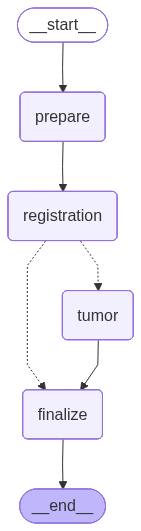

In [35]:
def finalize_node(state: PipelineState) -> PipelineState:
    case_result_dir = Path(state["case_result_dir"])
    summary = {
        "case": state["case"],
        "input_format": state.get("input_format"),
        "registration_success": state.get("registration_success", False),
        "failed_reason": state.get("failed_reason"),
        "registration_attempts": len(state.get("attempts", [])),
        "final_attempt_dir": state.get("final_attempt_dir"),
        "final_liver_dice": state.get("final_liver_dice"),
        "attempts": state.get("attempts", []),
        "tumor_metrics": state.get("tumor_metrics", {}),
    }
    summary_path = case_result_dir / "summary.json"
    write_json(summary_path, summary)
    state["summary_path"] = str(summary_path)
    return state


def build_graph():
    graph = StateGraph(PipelineState)
    graph.add_node("prepare", prepare_case_node)
    graph.add_node("registration", registration_loop_node)
    graph.add_node("tumor", tumor_extraction_node)
    graph.add_node("finalize", finalize_node)

    graph.add_edge(START, "prepare")
    graph.add_edge("prepare", "registration")
    graph.add_conditional_edges(
        "registration",
        route_after_registration,
        {"tumor": "tumor", "finalize": "finalize"},
    )
    graph.add_edge("tumor", "finalize")
    graph.add_edge("finalize", END)
    return graph.compile()

pipeline_graph = build_graph()
pipeline_graph


## Single Mode

Set `SINGLE_CASE_ID` to a case id such as `7088634_20170515` or `1043712`. If it is `None`, the first available test case is used.


In [36]:
nnunet_name_report = validate_nnunet_test_case_names(CFG)
write_json(Path(CFG.results_root) / "nnunet_test_case_name_report.json", nnunet_name_report)
for dataset_name, report in nnunet_name_report["datasets"].items():
    print(
        dataset_name,
        "same_set=", report["same_set_as_excel_test_split"],
        "non_3_channel_cases=", len(report["non_3_channel_cases"]),
        "missing=", report["missing_from_nnunet"],
        "extra=", report["extra_in_nnunet"],
    )

SINGLE_CASE_ID = '1309662'  # example: "7088634_20170515" or "1043712"

test_cases = get_test_cases(CFG)
if SINGLE_CASE_ID is None:
    single_case = test_cases[0]
else:
    single_case = next(case for case in test_cases if case["case_id"] == SINGLE_CASE_ID)

single_result = pipeline_graph.invoke({"cfg": CFG, "case": single_case})
single_result["summary_path"]


Dataset001 same_set= True non_3_channel_cases= 0 missing= [] extra= []
Dataset002 same_set= True non_3_channel_cases= 0 missing= [] extra= []

Liver Extraction Pipeline
Registration folder : Results/1309662/input
Liver output folder : Results/1309662/input/liver_images

  Processing phase A...
  Running TotalSegmentator for phase A...

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.44s
Predicting...


100%|██████████| 1/1 [00:00<00:00,  4.67it/s]


  Predicted in 6.40s
Resampling...
  cropping from (384, 384, 96) to (304, 316, 72)
Resampling...
  Resampled in 0.26s
Predicting...


100%|██████████| 1/1 [00:00<00:00, 10.72it/s]


  Predicted in 5.06s
Resampling...
Saving segmentations...
  Saved in 0.77s
  ✓ Saved liver-masked image: A_liver.nii.gz
  ✓ Phase A completed

  Processing phase P...
  Running TotalSegmentator for phase P...

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.40s
Predicting...


...

100%|██████████| 1/1 [00:00<00:00,  7.56it/s]


  Predicted in 5.98s
Resampling...
Saving segmentations...
  Saved in 0.76s
  ✓ Saved liver-masked image: D_liver.nii.gz
  ✓ Phase D completed
  ✓ Saved representative liver mask: Results/1309662/input/liver.nii.gz

Summary: 3/3 phases completed successfully


/home/sonwonjun/anaconda3/envs/MGH/lib/python3.13/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/sonwonjun/anaconda3/envs/MGH/lib/python3.13/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/a

skip sam3d_adapter: checkpoint not found -> ./checkpoints/sam_adapter/best_model.pt
nnUNetv2 failed. See Results/1309662/tumor/nnunetv2/nnunetv2_predict.log


'Results/1309662/summary.json'

## Batch Mode

Set `RUN_BATCH = True` to process all test cases. Results are saved independently under `Results/{case_id}/`.


In [ ]:
RUN_BATCH = False

batch_summaries = []
if RUN_BATCH:
    for case in get_test_cases(CFG):
        print(f"\n=== Running {case['case_id']} ===")
        result = pipeline_graph.invoke({"cfg": CFG, "case": case})
        batch_summaries.append(result["summary_path"])

    write_json(Path(CFG.results_root) / "batch_summary.json", {"summaries": batch_summaries})

batch_summaries[:5]
